# Seq2Seq LSTM + Bahdanau Attention — French → English

Architecture overview:
- **Encoder**: Bidirectional LSTM (custom cells) with learned positional embeddings
- **Attention**: Additive / Bahdanau — score computed from previous decoder state and all encoder outputs
- **Decoder**: Unidirectional LSTM (custom cells) with teacher forcing during training
- **Decoder init**: initial hidden state `s0 = tanh(W [h_fwd; h_bwd])`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_from_disk
from transformers import AutoTokenizer
from tqdm.auto import tqdm

In [4]:



base_path = Path("/content/drive/MyDrive/translation dataset")

tokenizer_en = AutoTokenizer.from_pretrained(
    str(base_path / "tokenizer_en-20260501T222425Z-3-001" / "tokenizer_en")
)
tokenizer_fr = AutoTokenizer.from_pretrained(
    str(base_path / "tokenizer_fr-20260501T222428Z-3-001" / "tokenizer_fr")
)

V_encoder = tokenizer_fr.vocab_size   # source (French)
V_decoder = tokenizer_en.vocab_size   # target (English)

fr_pad_id = tokenizer_fr.pad_token_id
en_pad_id = tokenizer_en.pad_token_id
bos_id    = tokenizer_en.bos_token_id
eos_id    = tokenizer_en.eos_token_id

print(f"Encoder (FR) vocab : {V_encoder}")
print(f"Decoder (EN) vocab : {V_decoder}")
print(f"FR pad id          : {fr_pad_id}")
print(f"EN pad / bos / eos : {en_pad_id} / {bos_id} / {eos_id}")

Encoder (FR) vocab : 3200
Decoder (EN) vocab : 3200
FR pad id          : 3
EN pad / bos / eos : 3 / 1 / 2


In [5]:
# ── Model ──────────────────────────────────────────────────────────────────────
EMBED_SIZE     = 256
HIDDEN_SIZE    = 512
NUM_LAYERS     = 1
LSTM_DROPOUT   = 0.3
BIDIRECTIONAL  = True
MAX_SRC_LEN    = 128
MAX_TGT_LEN    = 32

# ── Training ───────────────────────────────────────────────────────────────────
BATCH_SIZE     = 32
MAX_EPOCHS     = 10
LR             = 1e-3
GRAD_CLIP      = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

Using device: cuda


In [7]:
train_hf = load_from_disk(str(base_path/"parallel_en_fr_corpus-20260501T222423Z-3-001"/"parallel_en_fr_corpus" / "train"))
valid_hf = load_from_disk(str(base_path/"parallel_en_fr_corpus-20260501T222423Z-3-001" /"parallel_en_fr_corpus"/ "validation"))
test_hf  = load_from_disk(str(base_path /"parallel_en_fr_corpus-20260501T222423Z-3-001"/"parallel_en_fr_corpus" / "test"))


class NMTDataset(Dataset):
    def __init__(self, hf_dataset, tok_fr, tok_en, max_len: int = 32):
        self.data    = hf_dataset
        self.tok_fr  = tok_fr
        self.tok_en  = tok_en
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        fr_text = self.data[idx]["text_fr"]
        en_text = self.data[idx]["text_en"]

        enc = self.tok_fr(
            fr_text, max_length=self.max_len,
            padding="max_length", truncation=True, return_tensors="pt",
        )
        dec = self.tok_en(
            en_text, max_length=self.max_len,
            padding="max_length", truncation=True, return_tensors="pt",
        )
        return {
            "encoder_input": enc["input_ids"].squeeze(0),  # (src_len,)
            "decoder_input": dec["input_ids"].squeeze(0),  # (tgt_len,)
        }


train_dataset = NMTDataset(train_hf, tokenizer_fr, tokenizer_en, max_len=MAX_TGT_LEN)
valid_dataset = NMTDataset(valid_hf, tokenizer_fr, tokenizer_en, max_len=MAX_TGT_LEN)
test_dataset  = NMTDataset(test_hf,  tokenizer_fr, tokenizer_en, max_len=MAX_TGT_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train / Valid / Test: {len(train_dataset)} / {len(valid_dataset)} / {len(test_dataset)} samples")

Train / Valid / Test: 8701 / 485 / 486 samples


In [8]:
class TokenPositionalEmbedding(nn.Module):
    """Learnable token + positional embeddings (no sinusoidal)."""

    def __init__(self, vocab_size: int, embed_size: int, max_len: int = 128):
        super().__init__()
        self.token_weight = nn.Parameter(torch.randn(vocab_size, embed_size) * 0.02)
        self.pos_weight   = nn.Parameter(torch.randn(max_len,   embed_size) * 0.02)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        # input_ids: (batch, seq_len)
        batch, seq_len = input_ids.shape
        positions = torch.arange(seq_len, device=input_ids.device)

        tok_emb = self.token_weight[input_ids]                          # (batch, seq_len, E)
        pos_emb = self.pos_weight[positions].unsqueeze(0).expand(batch, -1, -1)  # (batch, seq_len, E)
        return tok_emb + pos_emb

In [9]:
class LSTMCell(nn.Module):
    """Single LSTM cell: computes (h_next, c_next) from (x_t, h_t, c_t)."""

    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.x2h = nn.Linear(input_size, 4 * hidden_size)
        self.h2h = nn.Linear(hidden_size, 4 * hidden_size, bias=False)

    def forward(self, x_t, h_t, c_t):
        gates = self.x2h(x_t) + self.h2h(h_t)
        i, f, g, o = gates.chunk(4, dim=-1)
        c_next = torch.sigmoid(f) * c_t + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

In [11]:
class BiLSTMEncoder(nn.Module):
    """
    Bidirectional LSTM encoder built from custom LSTMCells.
    Returns:
        outputs : (batch, src_len, 2*H)  — concatenated fwd+bwd at each step
        (h_n, c_n) : each (num_layers*2, batch, H)
    """

    def __init__(self, vocab_size, embed_size, hidden_size,
                 num_layers=1, dropout=0.0, bidirectional=True,
                 pad_id=None, max_len=128):
        super().__init__()
        self.hidden_size   = hidden_size
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.dropout       = dropout

        self.embedding = TokenPositionalEmbedding(vocab_size, embed_size, max_len)
        self.fwd_cells  = nn.ModuleList()
        self.bwd_cells  = nn.ModuleList()

        for layer in range(num_layers):
            in_size = embed_size if layer == 0 else hidden_size
            self.fwd_cells.append(LSTMCell(in_size, hidden_size))
            if bidirectional:
                self.bwd_cells.append(LSTMCell(in_size, hidden_size))

    def _run_direction(self, x, cells, reverse=False):
        batch, seq_len, _ = x.shape
        layer_input = x
        h_n_list, c_n_list = [], []

        for layer, cell in enumerate(cells):
            h_t = x.new_zeros(batch, self.hidden_size)
            c_t = x.new_zeros(batch, self.hidden_size)
            steps = range(seq_len - 1, -1, -1) if reverse else range(seq_len)
            outputs = []

            for t in steps:
                h_t, c_t = cell(layer_input[:, t, :], h_t, c_t)
                outputs.append(h_t)

            if reverse:
                outputs = outputs[::-1]

            layer_output = torch.stack(outputs, dim=1)   # (batch, seq_len, H)
            if self.dropout > 0.0 and layer < self.num_layers - 1:
                layer_output = F.dropout(layer_output, p=self.dropout, training=self.training)

            layer_input = layer_output
            h_n_list.append(h_t)
            c_n_list.append(c_t)

        return layer_input, torch.stack(h_n_list), torch.stack(c_n_list)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        fwd_out, fwd_h, fwd_c = self._run_direction(x, self.fwd_cells, reverse=False)

        if self.bidirectional:
            bwd_out, bwd_h, bwd_c = self._run_direction(x, self.bwd_cells, reverse=True)
            outputs = torch.cat([fwd_out, bwd_out], dim=2)
            h_n = torch.cat([torch.stack([fwd_h[i], bwd_h[i]]) for i in range(self.num_layers)])
            c_n = torch.cat([torch.stack([fwd_c[i], bwd_c[i]]) for i in range(self.num_layers)])
        else:
            outputs, h_n, c_n = fwd_out, fwd_h, fwd_c

        return outputs, (h_n, c_n)

In [12]:
class DecoderInit(nn.Module):
    """
    Projects the encoder's final bidirectional state to the decoder's
    initial hidden state:  s0 = tanh(W [h_fwd ; h_bwd])
    """

    def __init__(self, hidden_size: int):
        super().__init__()
        self.linear = nn.Linear(2 * hidden_size, hidden_size)

    def forward(self, h_n: torch.Tensor) -> torch.Tensor:
        # h_n: (num_layers * num_directions, batch, H)
        # last layer: forward = h_n[-2], backward = h_n[-1]
        cat = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (batch, 2H)
        return torch.tanh(self.linear(cat))           # (batch, H)

In [13]:
class AdditiveAttention(nn.Module):
    """
    Bahdanau additive attention:
        e_{t,i} = v^T tanh(W_a s_{t-1} + U_a h_i)
        alpha   = softmax(e)
        context = sum_i alpha_i h_i
    """

    def __init__(self, dec_hidden: int, enc_dim: int, attn_dim: int = None):
        super().__init__()
        attn_dim  = attn_dim or dec_hidden
        self.W_a  = nn.Linear(dec_hidden, attn_dim, bias=False)
        self.U_a  = nn.Linear(enc_dim,    attn_dim, bias=False)
        self.v    = nn.Linear(attn_dim,   1,         bias=False)

    def forward(self, s_prev, encoder_outputs, mask=None):
        # s_prev          : (batch, dec_hidden)
        # encoder_outputs : (batch, src_len, enc_dim)
        Wa    = self.W_a(s_prev).unsqueeze(1)                # (batch, 1, attn_dim)
        Ua    = self.U_a(encoder_outputs)                    # (batch, src_len, attn_dim)
        e     = self.v(torch.tanh(Wa + Ua)).squeeze(-1)      # (batch, src_len)

        if mask is not None:
            e = e.masked_fill(mask == 0, -1e9)

        alpha   = F.softmax(e, dim=1)                        # (batch, src_len)
        context = torch.bmm(alpha.unsqueeze(1), encoder_outputs).squeeze(1)  # (batch, enc_dim)
        return context, alpha


class UnidirectionalDecoder(nn.Module):
    """
    Unidirectional LSTM decoder with Bahdanau attention.
    Attention is computed using s_{t-1} (previous hidden) before the cell update.

    forward() uses full teacher forcing:
        - input  : decoder_input[:, :-1]  (all but last token, i.e. BOS … w_{T-1})
        - targets: decoder_input[:, 1:]   (all but first token, i.e. w_1 … EOS)
    Returns:
        logits      : (batch, tgt_len, vocab_size)
        (h_n, c_n)  : final states
        attn_weights: (batch, tgt_len, src_len) or None
    """

    def __init__(self, vocab_size, embed_size, hidden_size,
                 num_layers=1, dropout=0.0,
                 enc_dim=None, pad_id=None, max_len=128):
        super().__init__()
        self.hidden_size   = hidden_size
        self.num_layers    = num_layers
        self.use_attention = enc_dim is not None

        self.embedding     = TokenPositionalEmbedding(vocab_size, embed_size, max_len)
        self.cells         = nn.ModuleList()
        self.dropout_layer = nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()

        for layer in range(num_layers):
            in_size = embed_size if layer == 0 else hidden_size
            self.cells.append(LSTMCell(in_size, hidden_size))

        if self.use_attention:
            self.attn        = AdditiveAttention(hidden_size, enc_dim, attn_dim=hidden_size)
            self.attn_combine = nn.Linear(hidden_size + enc_dim, hidden_size)

        self.out_proj = nn.Linear(hidden_size, vocab_size)

    def forward(self, target_ids, s0=None, encoder_outputs=None, src_mask=None):
        batch, tgt_len = target_ids.shape
        emb = self.embedding(target_ids)   # (batch, tgt_len, E)

        # Initialise layer-wise hidden / cell states
        h = [torch.zeros(batch, self.hidden_size, device=target_ids.device) for _ in range(self.num_layers)]
        c = [torch.zeros(batch, self.hidden_size, device=target_ids.device) for _ in range(self.num_layers)]
        if s0 is not None:
            h[0] = s0   # layer-0 seeded from encoder

        outputs, attn_list = [], []

        for t in range(tgt_len):
            # 1. Compute attention using s_{t-1} (h[0] before the update)
            context = None
            if self.use_attention and encoder_outputs is not None:
                context, alpha = self.attn(h[0], encoder_outputs, mask=src_mask)
                attn_list.append(alpha)

            # 2. Step through stacked LSTM cells
            x = emb[:, t, :]
            for layer, cell in enumerate(self.cells):
                h[layer], c[layer] = cell(x, h[layer], c[layer])
                x = h[layer]
                if layer < self.num_layers - 1:
                    x = self.dropout_layer(x)

            # 3. Combine top hidden with context vector
            top_h = h[-1]
            if context is not None:
                out_vec = torch.tanh(self.attn_combine(torch.cat([top_h, context], dim=1)))
            else:
                out_vec = top_h

            outputs.append(self.out_proj(out_vec).unsqueeze(1))  # (batch, 1, V)

        logits       = torch.cat(outputs, dim=1)                 # (batch, tgt_len, V)
        h_n          = torch.stack(h)
        c_n          = torch.stack(c)
        attn_weights = torch.stack(attn_list).permute(1, 0, 2) if attn_list else None
        return logits, (h_n, c_n), attn_weights

In [14]:
enc_dim = 2 * HIDDEN_SIZE if BIDIRECTIONAL else HIDDEN_SIZE

encoder      = BiLSTMEncoder(
    vocab_size=V_encoder, embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS, dropout=LSTM_DROPOUT,
    bidirectional=BIDIRECTIONAL, max_len=MAX_SRC_LEN,
).to(device)

decoder_init = DecoderInit(HIDDEN_SIZE).to(device)

decoder      = UnidirectionalDecoder(
    vocab_size=V_decoder, embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS, dropout=LSTM_DROPOUT,
    enc_dim=enc_dim, pad_id=en_pad_id, max_len=MAX_TGT_LEN,
).to(device)

total_params = sum(p.numel() for p in
    list(encoder.parameters()) + list(decoder_init.parameters()) + list(decoder.parameters())
    if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 10,144,384


In [15]:
# ── Quick forward-pass sanity check (no gradient needed) ──────────────────────
encoder.eval(); decoder_init.eval(); decoder.eval()

with torch.no_grad():
    _batch          = next(iter(train_loader))
    _src            = _batch["encoder_input"].to(device)
    _tgt            = _batch["decoder_input"].to(device)
    _enc_out, (h_n, _) = encoder(_src)
    _s0             = decoder_init(h_n)
    _src_mask       = (_src != fr_pad_id)
    _logits, _, _aw = decoder(_tgt, s0=_s0, encoder_outputs=_enc_out, src_mask=_src_mask)

print(f"encoder_outputs : {_enc_out.shape}")   # (B, src_len, 2H)
print(f"s0              : {_s0.shape}")         # (B, H)
print(f"logits          : {_logits.shape}")     # (B, tgt_len, V_dec)
print(f"attn_weights    : {_aw.shape}")         # (B, tgt_len, src_len)

encoder_outputs : torch.Size([32, 32, 1024])
s0              : torch.Size([32, 512])
logits          : torch.Size([32, 32, 3200])
attn_weights    : torch.Size([32, 32, 32])


In [16]:
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder_init.parameters()) + list(decoder.parameters()),
    lr=LR,
)
criterion = nn.CrossEntropyLoss(ignore_index=en_pad_id)

train_losses, val_losses = [], []
best_val_loss = float("inf")

for epoch in range(MAX_EPOCHS):

    # ── Training ──────────────────────────────────────────────────────────────
    encoder.train(); decoder_init.train(); decoder.train()
    epoch_loss = 0.0
    start = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{MAX_EPOCHS} [train]", leave=True)
    for step, batch in enumerate(pbar):
        src = batch["encoder_input"].to(device)   # (B, src_len)
        tgt = batch["decoder_input"].to(device)   # (B, tgt_len)

        # ── FIX: zero gradients BEFORE the forward pass ──────────────────────
        optimizer.zero_grad()

        # Forward
        encoder_outputs, (h_n, _) = encoder(src)
        s0                         = decoder_init(h_n)
        src_mask                   = (src != fr_pad_id)

        # Teacher forcing: feed tgt[t], predict tgt[t+1]
        logits, _, _ = decoder(tgt, s0=s0, encoder_outputs=encoder_outputs, src_mask=src_mask)
        logits_flat  = logits[:, :-1, :].contiguous().view(-1, logits.size(-1))
        targets_flat = tgt[:, 1:].contiguous().view(-1)

        loss = criterion(logits_flat, targets_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder_init.parameters()) + list(decoder.parameters()),
            max_norm=GRAD_CLIP,
        )
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(avg_loss=f"{epoch_loss / (step + 1):.4f}")

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation (full pass) ────────────────────────────────────────────────
    # FIX: evaluate over the entire validation set, not just one batch
    # FIX: decoder_init.eval() was missing
    encoder.eval(); decoder_init.eval(); decoder.eval()
    val_loss_total = 0.0

    with torch.no_grad():
        for val_batch in tqdm(valid_loader, desc=f"Epoch {epoch+1:02d}/{MAX_EPOCHS} [valid]", leave=False):
            src = val_batch["encoder_input"].to(device)
            tgt = val_batch["decoder_input"].to(device)

            encoder_outputs, (h_n, _) = encoder(src)
            s0                         = decoder_init(h_n)
            src_mask                   = (src != fr_pad_id)

            logits, _, _ = decoder(tgt, s0=s0, encoder_outputs=encoder_outputs, src_mask=src_mask)
            logits_flat  = logits[:, :-1, :].contiguous().view(-1, logits.size(-1))
            targets_flat = tgt[:, 1:].contiguous().view(-1)

            val_loss_total += criterion(logits_flat, targets_flat).item()

    avg_val_loss = val_loss_total / len(valid_loader)
    val_losses.append(avg_val_loss)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1:02d} | train_loss {avg_train_loss:.4f} | val_loss {avg_val_loss:.4f} | {elapsed:.1f}s")

    # Save best checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            "epoch":        epoch + 1,
            "encoder":      encoder.state_dict(),
            "decoder_init": decoder_init.state_dict(),
            "decoder":      decoder.state_dict(),
            "optimizer":    optimizer.state_dict(),
            "val_loss":     best_val_loss,
        }, "best_checkpoint.pt")
        print(f"  → New best checkpoint saved (val_loss={best_val_loss:.4f})")

print("Training complete.")

Epoch 01/10 [train]:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 01/10 [valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 01 | train_loss 3.3073 | val_loss 2.3840 | 41.9s
  → New best checkpoint saved (val_loss=2.3840)


Epoch 02/10 [train]:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 02/10 [valid]:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 09/10 [valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 09 | train_loss 0.2448 | val_loss 1.3425 | 52.7s


Epoch 10/10 [train]:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 10/10 [valid]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 10 | train_loss 0.1755 | val_loss 1.3582 | 132.1s
Training complete.


In [18]:
import heapq
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ── Beam Search ────────────────────────────────────────────────────────────────

def beam_search(encoder, decoder_init, decoder, src_ids,
                bos_id, eos_id, pad_id,
                beam_width=4, max_steps=50, length_penalty=0.7):
    """
    Beam search for a single source sequence.

    Args:
        src_ids      : (1, src_len) int tensor on device
        beam_width   : number of beams to keep
        max_steps    : maximum decoding steps
        length_penalty: LP = ((5 + len) / 6) ^ alpha  (Wu et al., 2016)

    Returns:
        best_ids : list[int] — best token sequence (without BOS, stops at EOS)
    """
    device = src_ids.device
    encoder.eval(); decoder_init.eval(); decoder.eval()

    with torch.no_grad():
        # ── Encode ──────────────────────────────────────────────────────────
        enc_out, (h_n, _) = encoder(src_ids)           # (1, src_len, 2H)
        s0                 = decoder_init(h_n)           # (1, H)
        src_mask           = (src_ids != pad_id)        # (1, src_len)

        # Each beam state: (neg_log_prob, token_list, h_list, c_list)
        init_h = [s0.squeeze(0)] + [
            torch.zeros(decoder.hidden_size, device=device)
            for _ in range(decoder.num_layers - 1)
        ]
        init_c = [torch.zeros(decoder.hidden_size, device=device)
                  for _ in range(decoder.num_layers)]

        # Heap entries: (score, seq, h_layers, c_layers)
        beams     = [(0.0, [bos_id], init_h, init_c)]
        completed = []

        for _ in range(max_steps):
            candidates = []

            for score, seq, h_layers, c_layers in beams:
                if seq[-1] == eos_id:
                    completed.append((score, seq))
                    continue

                # Prepare single-step input
                tok   = torch.tensor([[seq[-1]]], device=device)       # (1, 1)
                x    = decoder.embedding(tok).squeeze(1)              # (1, E)

                # Attention with last layer-0 hidden
                h0_expanded = h_layers[0].unsqueeze(0)               # (1, H)
                context, _  = decoder.attn(h0_expanded, enc_out, mask=src_mask)
                # context: (1, enc_dim)

                # Step through LSTM cells
                new_h, new_c = list(h_layers), list(c_layers)
                inp = x
                for layer, cell in enumerate(decoder.cells):
                    new_h[layer], new_c[layer] = cell(inp, new_h[layer].unsqueeze(0), new_c[layer].unsqueeze(0))
                    new_h[layer] = new_h[layer].squeeze(0)
                    new_c[layer] = new_c[layer].squeeze(0)
                    inp = new_h[layer].unsqueeze(0)
                    if layer < decoder.num_layers - 1:
                        inp = decoder.dropout_layer(inp)

                top_h      = new_h[-1].unsqueeze(0)                  # (1, H)
                combined   = torch.tanh(decoder.attn_combine(
                                torch.cat([top_h, context], dim=1))) # (1, H)
                logits     = decoder.out_proj(combined)               # (1, V)
                log_probs  = F.log_softmax(logits, dim=-1).squeeze(0) # (V,)

                topk_lp, topk_ids = log_probs.topk(beam_width)
                for lp, tid in zip(topk_lp.tolist(), topk_ids.tolist()):
                    candidates.append((
                        score - lp,           # negate so heapq gives min (= best)
                        seq + [tid],
                        new_h, new_c,
                    ))

            if not candidates:
                break

            # Keep top beam_width by length-penalised score
            def lp_score(entry):
                neg_score, seq, *_ = entry
                lp = ((5 + len(seq)) / 6) ** length_penalty
                return neg_score / lp

            beams = sorted(candidates, key=lp_score)[:beam_width]

            # Stop early if all beams have ended
            if all(s[-1] == eos_id for _, s, *_ in beams):
                completed += [(sc, sq) for sc, sq, *_ in beams]
                break

        # If nothing completed, take the best active beam
        if not completed:
            completed = [(sc, sq) for sc, sq, *_ in beams]

        def final_score(entry):
            neg_score, seq = entry
            lp = ((5 + len(seq)) / 6) ** length_penalty
            return neg_score / lp

        _, best_seq = min(completed, key=final_score)

    # Strip BOS; truncate at first EOS
    if best_seq and best_seq[0] == bos_id:
        best_seq = best_seq[1:]
    if eos_id in best_seq:
        best_seq = best_seq[:best_seq.index(eos_id)]

    return best_seq


# ── BLEU evaluation on the test set ───────────────────────────────────────────

def evaluate_bleu(encoder, decoder_init, decoder, loader,
                  tokenizer_en, tokenizer_fr,
                  bos_id, eos_id, pad_id,
                  beam_width=4, max_samples=500):
    """
    Compute corpus BLEU over `max_samples` examples from `loader`.
    Uses beam search for decoding.
    Returns bleu_score.
    """
    references, hypotheses = [], []
    samples_seen = 0

    encoder.eval(); decoder_init.eval(); decoder.eval()

    for batch in tqdm(loader, desc="BLEU evaluation"):
        src = batch["encoder_input"].to(device)    # (B, src_len)
        tgt = batch["decoder_input"].to(device)    # (B, tgt_len)

        for i in range(src.size(0)):
            if samples_seen >= max_samples:
                break

            pred_ids = beam_search(
                encoder, decoder_init, decoder,
                src[i].unsqueeze(0),
                bos_id=bos_id, eos_id=eos_id, pad_id=pad_id,
                beam_width=beam_width, max_steps=MAX_TGT_LEN,
            )

            # Reference: strip padding / BOS / EOS
            ref_ids  = tgt[i].tolist()
            if ref_ids[0] == bos_id:
                ref_ids = ref_ids[1:]
            if eos_id in ref_ids:
                ref_ids = ref_ids[:ref_ids.index(eos_id)]
            ref_ids  = [t for t in ref_ids if t != en_pad_id]

            references.append([ref_ids])    # corpus_bleu expects list-of-lists
            hypotheses.append(pred_ids)
            samples_seen += 1

        if samples_seen >= max_samples:
            break

    smoother   = SmoothingFunction().method4
    bleu_score = corpus_bleu(references, hypotheses, smoothing_function=smoother)

    return bleu_score


# ── Run ────────────────────────────────────────────────────────────────────────
bleu = evaluate_bleu(
    encoder, decoder_init, decoder, test_loader,
    tokenizer_en, tokenizer_fr,
    bos_id=bos_id, eos_id=eos_id, pad_id=en_pad_id,
    beam_width=4, max_samples=500,
)

print(f"\nCorpus BLEU (beam=4, n=500): {bleu * 100:.2f}\n")

BLEU evaluation:   0%|          | 0/16 [00:00<?, ?it/s]


Corpus BLEU (beam=4, n=500): 12.81



FR : on peut me faire confiance .
EN (Predicted): ▁i ▁m ▁growing ▁so ▁sorry ▁so ▁so ▁concerned ▁in ▁them ▁up ized ▁arguing ▁.
EN (Reference): i m trustworthy .



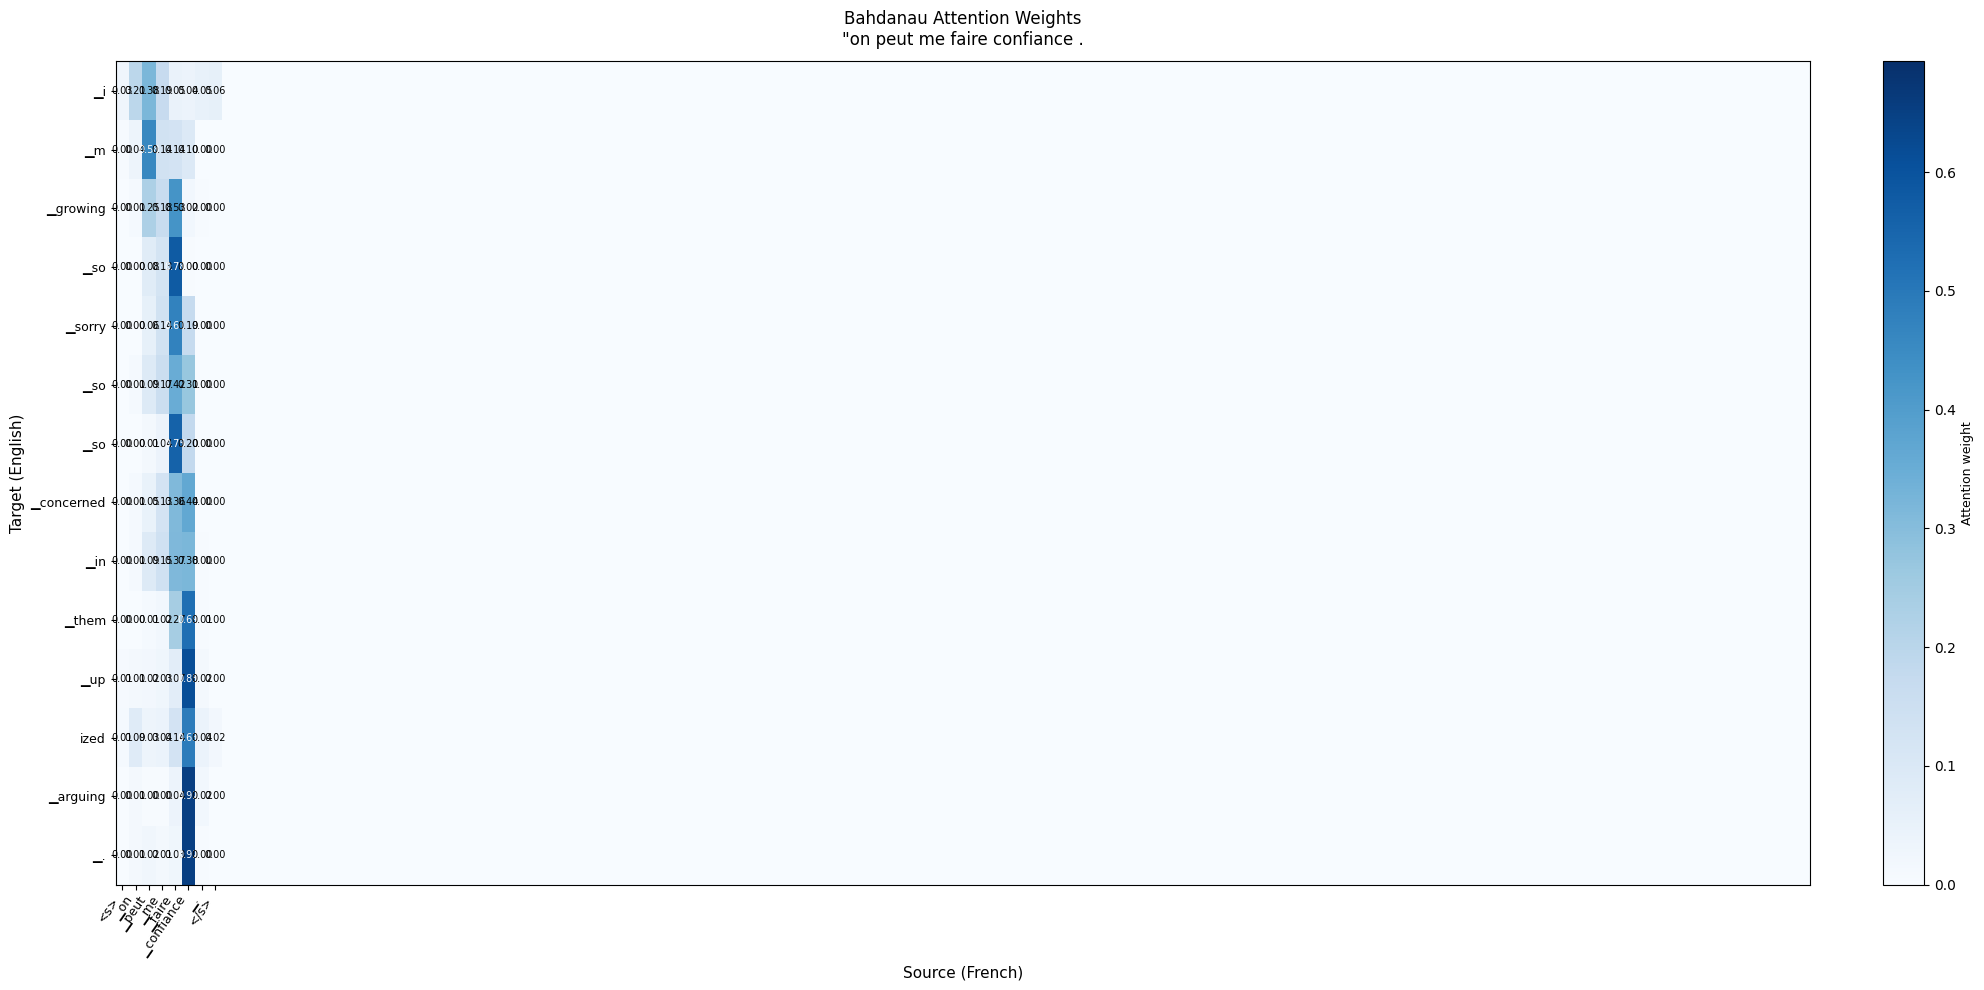

Saved → attention_heatmap.png
FR : je ne suis pas malheureux .
EN (Predicted): ▁i ▁m ▁not ▁unhappy ▁by ▁can mber mber mber ▁they ▁re ▁not ▁unhappy ▁up ▁loud ▁.
EN (Reference): i m not miserable .



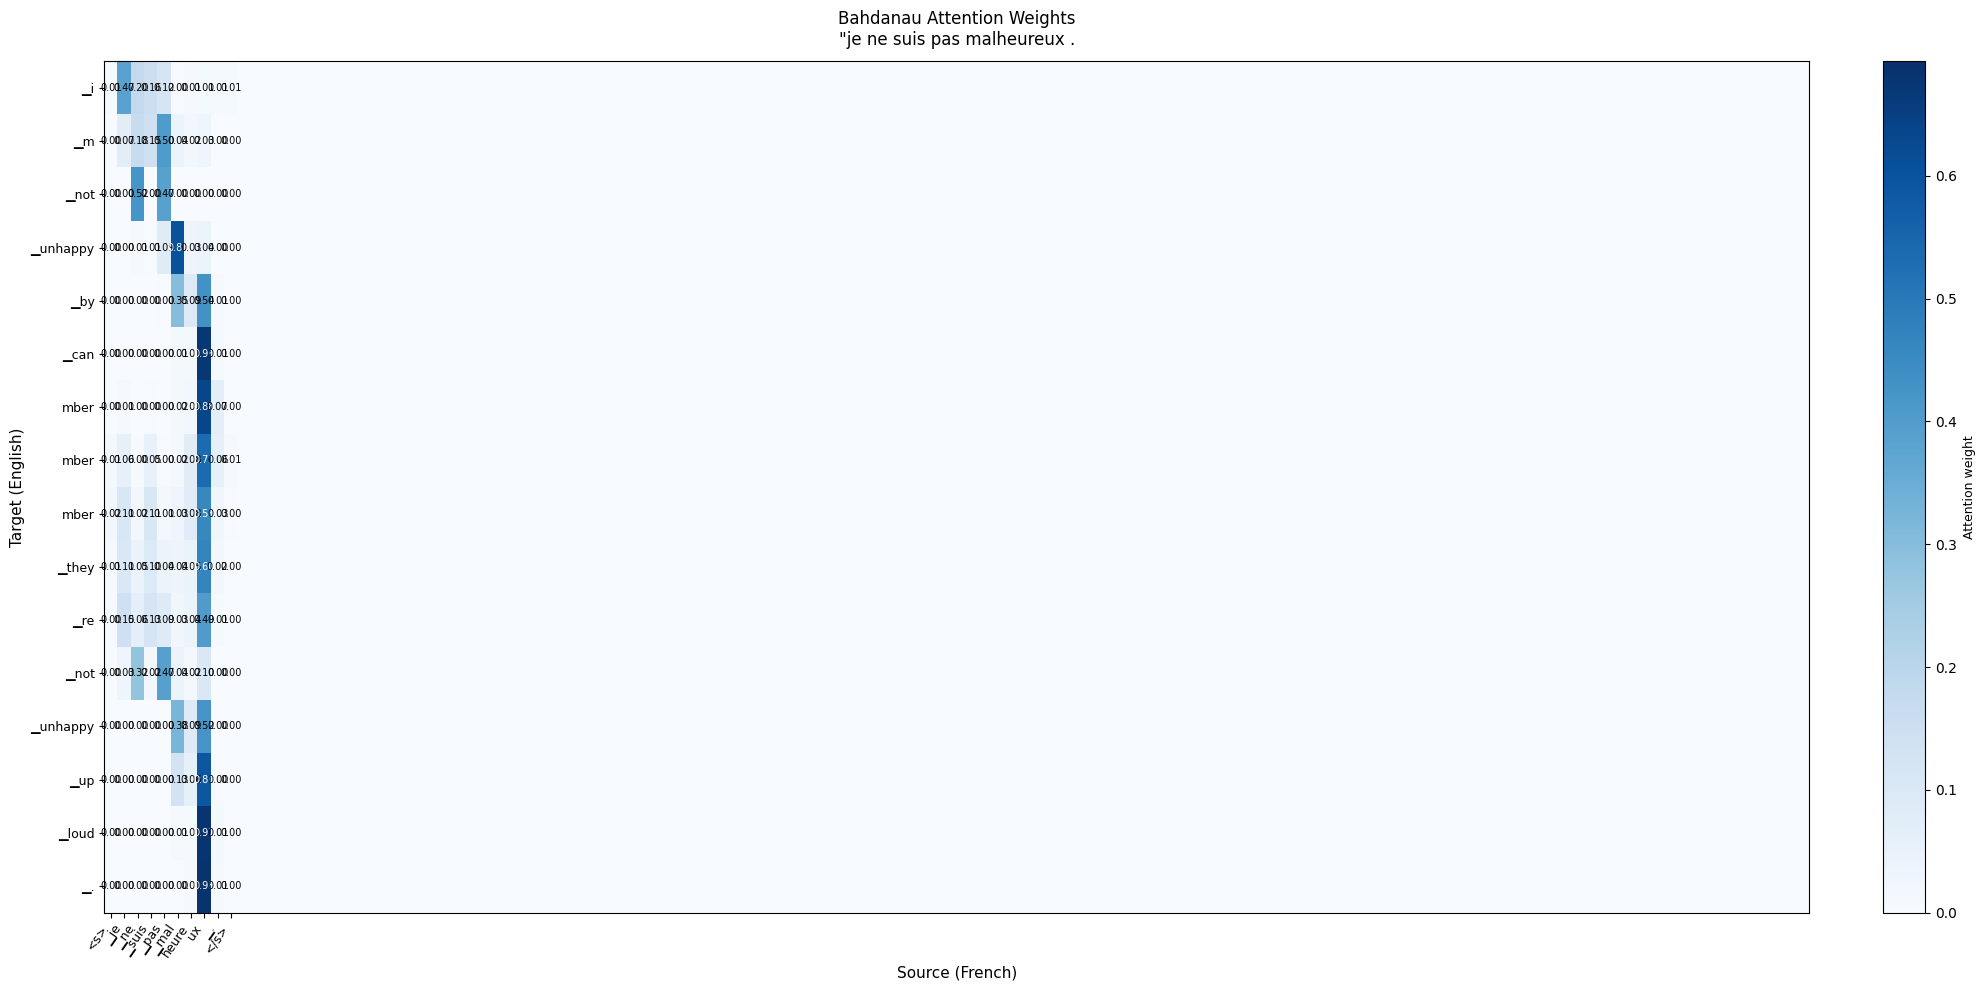

Saved → attention_heatmap.png
FR : je vais prendre ma voiture .
EN (Predicted): ▁i ▁m ▁going ▁taking ▁my ▁my ▁car ▁lawyer ▁my ▁car ▁lawyer ▁.
EN (Reference): i m going to take my car .



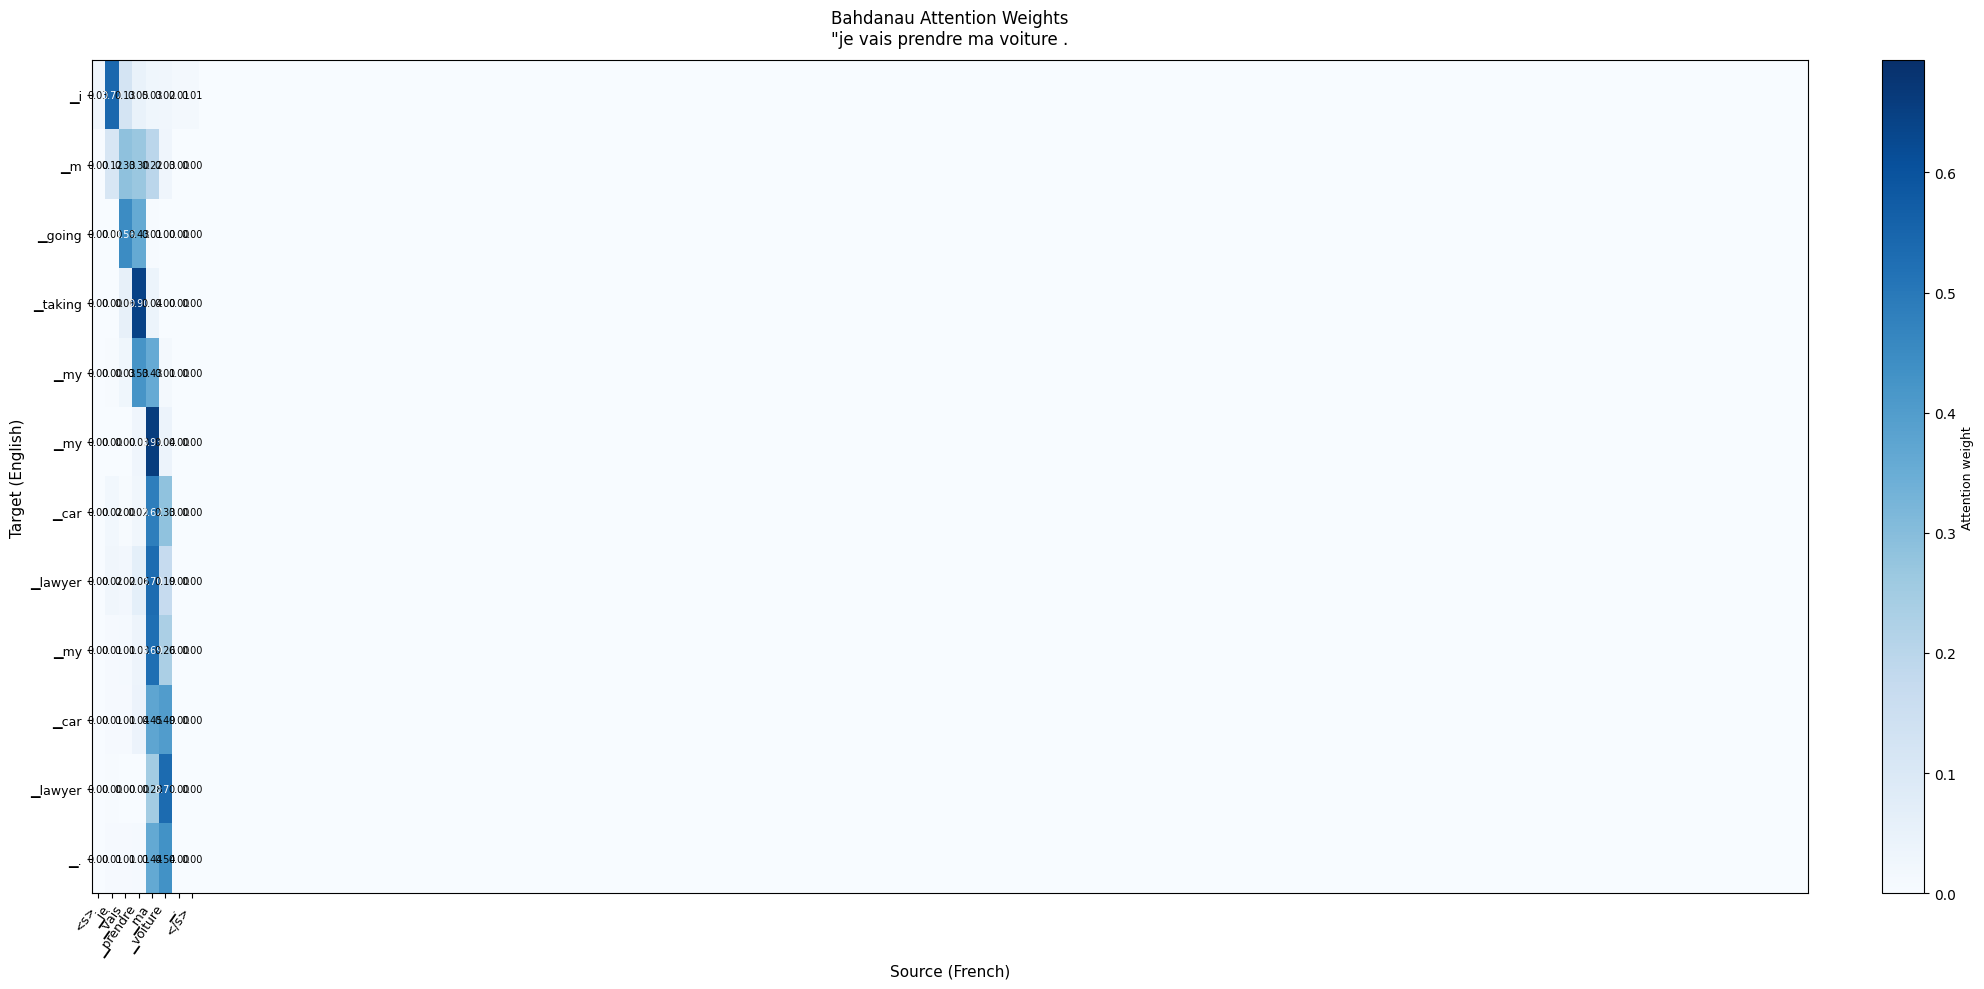

Saved → attention_heatmap.png


In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def get_attention_weights(
    encoder, decoder_init, decoder,
    src_text, tokenizer_fr, tokenizer_en,
    bos_id, eos_id, pad_id,
    max_src_len=MAX_SRC_LEN, max_tgt_len=MAX_TGT_LEN,
):
    """
    Encode `src_text` and decode with greedy search, collecting attention
    weights at every step.

    Returns:
        src_tokens  : list[str]  — French subword tokens
        tgt_tokens  : list[str]  — English subword tokens (decoded)
        attn_matrix : (tgt_len, src_len) numpy array
    """
    encoder.eval(); decoder_init.eval(); decoder.eval()

    enc_enc = tokenizer_fr(
        src_text, max_length=max_src_len,
        padding="max_length", truncation=True, return_tensors="pt",
    )
    src_ids  = enc_enc["input_ids"].to(device)              # (1, src_len)
    src_mask = (src_ids != pad_id)

    src_tokens = tokenizer_fr.convert_ids_to_tokens(src_ids[0].tolist())
    # Trim trailing [PAD]
    src_tokens = [t for t in src_tokens if t != tokenizer_fr.pad_token]

    with torch.no_grad():
        enc_out, (h_n, _) = encoder(src_ids)
        s0                 = decoder_init(h_n)

        h = [s0.squeeze(0)] + [
            torch.zeros(decoder.hidden_size, device=device)
            for _ in range(decoder.num_layers - 1)
        ]
        c = [torch.zeros(decoder.hidden_size, device=device)
             for _ in range(decoder.num_layers)]

        tgt_ids, attn_rows = [bos_id], []

        for _ in range(max_tgt_len):
            tok    = torch.tensor([[tgt_ids[-1]]], device=device)
            x      = decoder.embedding(tok).squeeze(1)           # (1, E)
            h0_exp = h[0].unsqueeze(0)
            context, alpha = decoder.attn(h0_exp, enc_out, mask=src_mask)
            attn_rows.append(alpha.squeeze(0).cpu().numpy())     # (src_len,)

            inp = x
            for layer, cell in enumerate(decoder.cells):
                h[layer], c[layer] = cell(inp, h[layer].unsqueeze(0), c[layer].unsqueeze(0))
                h[layer] = h[layer].squeeze(0)
                c[layer] = c[layer].squeeze(0)
                inp = h[layer].unsqueeze(0)
                if layer < decoder.num_layers - 1:
                    inp = decoder.dropout_layer(inp)

            top_h   = h[-1].unsqueeze(0)
            combined = torch.tanh(decoder.attn_combine(torch.cat([top_h, context], dim=1)))
            logits   = decoder.out_proj(combined)
            next_id  = logits.argmax(dim=-1).item()
            tgt_ids.append(next_id)

            if next_id == eos_id:
                break

    tgt_tokens  = tokenizer_en.convert_ids_to_tokens(tgt_ids[1:])  # skip BOS
    # Trim at EOS
    if tokenizer_en.eos_token in tgt_tokens:
        tgt_tokens = tgt_tokens[:tgt_tokens.index(tokenizer_en.eos_token)]

    attn_matrix = np.stack(attn_rows[:len(tgt_tokens)], axis=0)    # (T_tgt, src_len)
    src_display = src_tokens[:attn_matrix.shape[1]]                 # align lengths

    return src_display, tgt_tokens, attn_matrix


def plot_attention(src_tokens, tgt_tokens, attn_matrix,
                   src_text="", figsize=(20, 10), cmap="Blues", scale_type="linear"):
    """
    Plot a heatmap of attention weights.
        x-axis: source tokens (French)
        y-axis: target tokens (English)
    """
    fig, ax = plt.subplots(figsize=figsize)

    vmin, vmax = 0, 1
    if scale_type == "log":
        attn_matrix = np.log1p(attn_matrix) # Apply log(1+x) transformation
        vmin, vmax = 0, np.log(2) # log(1+0)=0, log(1+1)=log(2)

    im = ax.imshow(attn_matrix, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)

    # Axes labels
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=55, ha="right", fontsize=9)
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens, fontsize=9)

    ax.set_xlabel("Source (French)", fontsize=11)
    ax.set_ylabel("Target (English)", fontsize=11)
    ax.set_title(
        f"Bahdanau Attention Weights\n\"{src_text[:60]}{'…' if len(src_text)>60 else ''}",
        fontsize=12, pad=12,
    )

    # Colour bar
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.ax.set_ylabel("Attention weight", fontsize=9)

    # Annotate cells with weight values (original values, not logged)
    original_attn_matrix = np.expm1(attn_matrix) if scale_type == "log" else attn_matrix
    for row in range(len(tgt_tokens)):
        for col in range(len(src_tokens)):
            val = original_attn_matrix[row, col]
            color = "white" if val > 0.55 else "black"
            ax.text(col, row, f"{val:.2f}", ha="center", va="center",
                    fontsize=7, color=color)

    plt.tight_layout()
    plt.savefig("attention_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → attention_heatmap.png")


# ── Visualise a few examples from the test set ────────────────────────────────
NUM_EXAMPLES = 3
test_raw     = test_hf.select(range(NUM_EXAMPLES))

for ex in test_raw:
    fr_text = ex["text_fr"]
    src_tok, tgt_tok, attn_mat = get_attention_weights(
        encoder, decoder_init, decoder,
        fr_text, tokenizer_fr, tokenizer_en,
        bos_id=bos_id, eos_id=eos_id, pad_id=en_pad_id,
    )
    print(f"FR : {fr_text}")
    print(f"EN (Predicted): {tokenizer_en.convert_tokens_to_string(tgt_tok)}")
    print(f"EN (Reference): {ex['text_en']}\n")
    plot_attention(src_tok, tgt_tok, attn_mat, src_text=fr_text, scale_type="log")

## Live Translation Test

Enter a French sentence to see the model's translation and attention weights.

FR : je suis desole si je t ai derangee .
EN (Predicted): ▁i ▁m ▁sorry ▁if ▁i ▁disturbed ▁you ▁up ▁disturbed ▁you ▁are ▁if ▁have ▁disturbed ▁you ▁up ▁arguing ▁you ▁want ▁if ▁we ▁disturbed ▁you ▁re ▁worried ▁up ▁arguing ▁you ▁up ▁arguing ▁you ▁you
EN (Reference): i m sorry if i disturbed you .



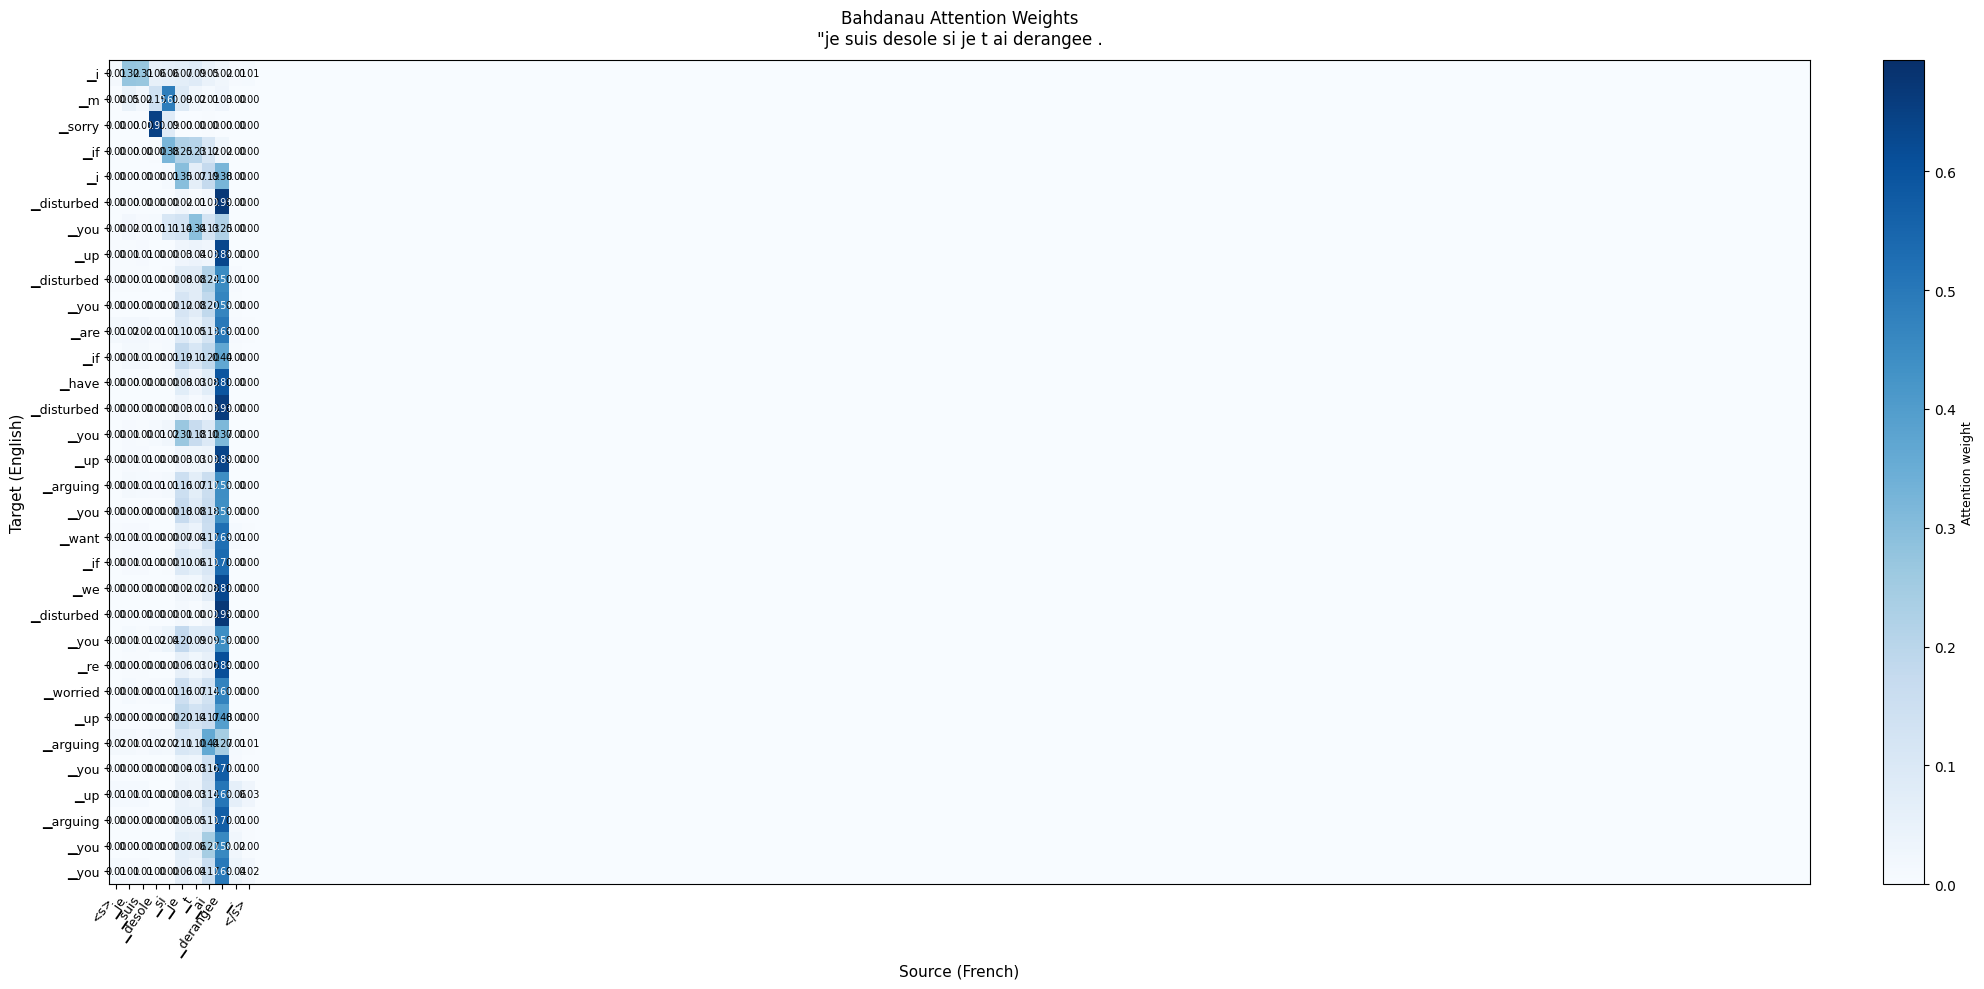

Saved → attention_heatmap.png


In [32]:
import random

# Select a random example from the test set
random_idx = random.randint(0, len(test_hf) - 1)
ex = test_hf[random_idx]
fr_sentence = ex["text_fr"]

src_tok, tgt_tok, attn_mat = get_attention_weights(
    encoder, decoder_init, decoder,
    fr_sentence, tokenizer_fr, tokenizer_en,
    bos_id=bos_id, eos_id=eos_id, pad_id=en_pad_id,
)

print(f"FR : {fr_sentence}")
print(f"EN (Predicted): {tokenizer_en.convert_tokens_to_string(tgt_tok)}")
print(f"EN (Reference): {ex['text_en']}\n")
plot_attention(src_tok, tgt_tok, attn_mat, src_text=fr_sentence, scale_type="log")